In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from scipy.integrate import solve_ivp
import timeit
from scipy.sparse import csr_array,block_array,eye,coo_array
import subprocess
import struct
from multiprocess import Pool
from IPython.display import Video,display
import networkx as nx

loadstr=''
try:
    loadstr='module load %s &&'%(subprocess.check_output("module avail | grep cuda/", shell=True, text=True).split()[-1])
except:
    pass

/bin/sh: 1: module: not found


Define coupling parameters for CGLE

$$
\frac{\partial A}{\partial t} = A + (1+ib)\nabla^2 A - (1-ic)|A|^2 A,
$$

which we separate into real and imaginary parts $A=X+iY$ with


$$
\frac{\partial X}{\partial t} = X + \nabla^2 X - b \nabla^2 Y - (X^2+Y^2)X - c (X^2+Y^2)Y, 
$$

$$
\frac{\partial Y}{\partial t} = Y + \nabla^2 Y + b \nabla^2 X - (X^2+Y^2)Y + c (X^2+Y^2)X.
$$

We can find the indices for the coupling terms with the help function with no filebase. We illustrate first in two spatial dimensions and later in one and three spatial dimensions.

In [2]:
Ns=[256,256]
Ls=[100.0,100.0]
T=10
dt=0.1
cmd='%s ./rdcu -N %i,%i -L %f,%f -n 2 -h'%(loadstr, Ns[0],Ns[1],Ls[0],Ls[1])
print(cmd)
os.system(cmd)

 ./rdcu -N 256,256 -L 100.000000,100.000000 -n 2 -h
usage:	rdcu [-hvSFR] [-n NFIELDS] [-N NUMS] [-L LENGTHS]
	[-c COUPLING] [-A AMPLITUDE] [-t TIME] [-d DT] [-s SEED] 
	[-D DENSITY] [-g GPU] [-r RTOL] [-a ATOL]  FILEBASE 

-h for help. Call with -n and -N to see Y indices. 
-v for verbose output, including progress 
-S for stiff system. Use the BDF method with finite differences instead of RK45 pseudospectral method. 
-F for fixed timestep 
-R to reload final state from FILEBASEfs.dat if possible
NFIELDS is the number of fields. Default 1
NUMS is number of grid points in each dimension (up to three), separated by commas (no spaces). Default 128
LENGTHS is domain length in each dimension (up to three), separated by commas (no spaces). Default 1.0
COUPLING is a list of coupling terms, separated by commas (no spaces). Default empty
	The first value is the term coefficent. 
	The second value is an integer specifying the field that the term appears in. 
	The following 2N values are pairs of

0

In [3]:
filebase='data/2dcgle'

b=2.0 
c=0.8
couplings=['1.0,0,0,1', '1.0,0,6,1', '1.0,0,12,1', '-%f,0,7,1'%(b), \
           '-%f,0,13,1'%(b), '-1.0,0,0,3', '-1.0,0,0,1,1,2', '1.0,1,1,1', \
           '1.0,1,7,1', '1.0,1,13,1', '%f,1,6,1'%(b),'%f,1,12,1'%(b), \
           '-1.0,1,0,2,1,1', '-1.0,1,1,3', '%f,1,0,3'%(c), '%f,1,0,1,1,2'%(c), \
           '-%f,0,0,2,1,1'%(c),'-%f,0,1,3'%(c)]

file=open('%scoupling.dat'%(filebase),'w')
for line in couplings:
    print(line,file=file)
file.close()

Explicit runge-kutta pseudospectral on the gpu

In [4]:
cmd='%s ./rdcu -t %f -d %f -N %i,%i -L %f,%f -n 2 -v -D1 %s'%(loadstr,T,dt,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

 ./rdcu -t 10.000000 -d 0.100000 -N 256,256 -L 100.000000,100.000000 -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
1.001	2.584e+01	-2.121e-02	0.012280	924	
runtime: 25.845386


0

runtime: 25.845386



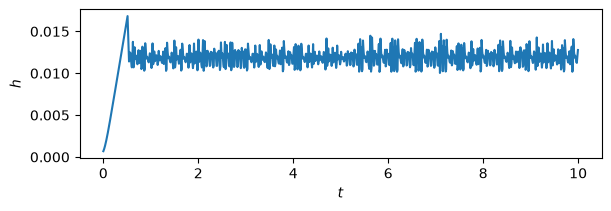

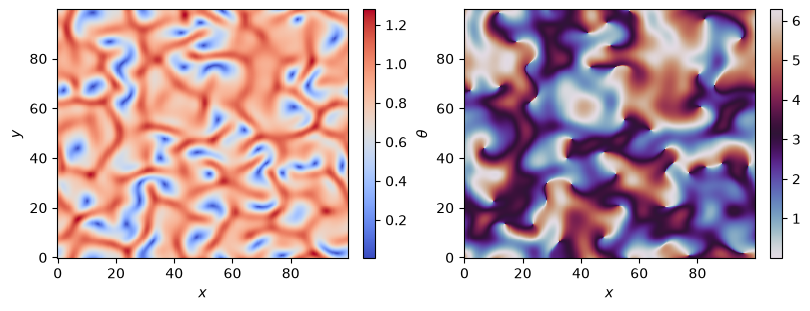

In [5]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
U0=ys[0].reshape(-1)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi
plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


implicit BDF with finite differences on gpu with the same initial condition. Note the first few timesteps are small before the BDF stabilizes.

In [6]:
cmd='%s ./rdcu -t %f -d %f -N %i,%i -L %f,%f -n 2 -v -S -D1 %s'%(loadstr,T,dt,Ns[0],Ns[1],Ls[0],Ls[1],filebase)

print(cmd)
os.system(cmd)

 ./rdcu -t 10.000000 -d 0.100000 -N 256,256 -L 100.000000,100.000000 -n 2 -v -S -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
1.002	2.390e+01	-5.336e-02	0.035750	629	
runtime: 23.954695


0

runtime: 23.954695



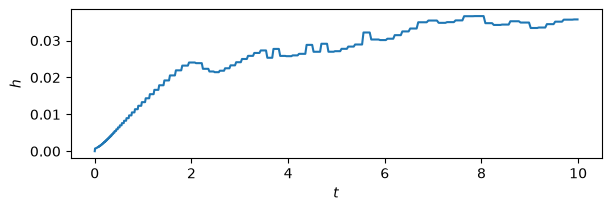

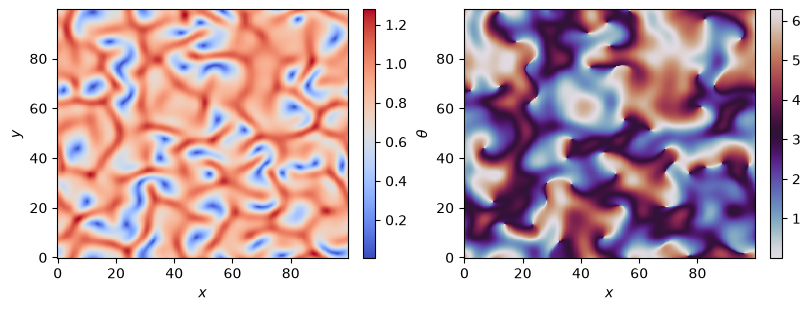

In [7]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


Explicit runge-kutta pseudospectral on the cpu. The GPU results are almost identical and much faster, and performance benefits increase with increasing Ns.

In [8]:
def lap(y,Ls,Ns):
    yfft=np.fft.fftn(y)
    ret=-np.fft.fftfreq(Ns[0],Ls[0]/(2*np.pi*Ns[0])).reshape((Ns[0],1))**2*yfft
    ret=ret-np.fft.fftfreq(Ns[1],Ls[1]/(2*np.pi*Ns[1])).reshape((1,Ns[1]))**2*yfft
    return np.fft.ifftn(ret)

def cgle(t, U, b, c, Ls, Ns):
    N=Ns[0]*Ns[1]
    X=U[:N].reshape(Ns)
    Y=U[N:].reshape(Ns)
    A=X+1j*Y
    lapA=lap(A,Ls,Ns)
    lapX=np.real(lapA)
    lapY=np.imag(lapA)
    retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    ret=np.zeros(U.shape)
    ret[:N]=retX.reshape(-1)
    ret[N:]=retY.reshape(-1)
    return ret

start=timeit.default_timer()
sol1=solve_ivp(cgle,[0,T],U0,args=[b,c,Ls,Ns],method='RK45',rtol=1E-8,atol=1E-8,first_step=0.03)
stop=timeit.default_timer()
print("runtime: ", stop-start, flush=True)

ys=sol1.y.reshape([2]+Ns+[-1]).transpose(3,0,1,2)
ts=sol1.t

runtime:  39.69344525100041


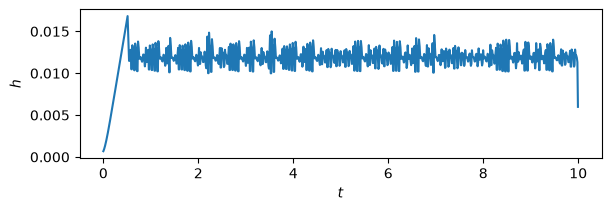

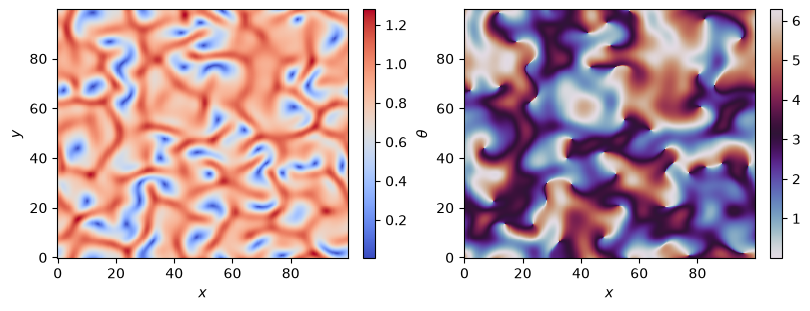

In [9]:
ys=sol1.y.reshape([2]+Ns+[-1]).transpose(3,0,1,2)
ts=sol1.t

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


implicit BDF with finite differences on cpu. The GPU results are again almost identical and are comparatively even faster. The sparse LU solver from scipy performs poorly compared to cudss and scales very poorly with increasing Ns.

In [10]:
def lap(y,Ls,Ns):
    return (np.roll(y,1,axis=0)+np.roll(y,-1,axis=0)-2*y)/(Ls[0]/Ns[0])**2+(np.roll(y,1,axis=1)+np.roll(y,-1,axis=1)-2*y)/(Ls[1]/Ns[1])**2

def cgle(t, U, b, c, Ls, Ns, I, JI):
    N=Ns[0]*Ns[1]
    X=U[:N].reshape(Ns)
    Y=U[N:].reshape(Ns)
    A=X+1j*Y
    lapA=lap(A,Ls,Ns)
    lapX=np.real(lapA)
    lapY=np.imag(lapA)
    retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    ret=np.zeros(U.shape)
    ret[:N]=retX.reshape(-1)
    ret[N:]=retY.reshape(-1)
    return ret

def jac(t, U, b, c, Ls, Ns, I, JI):
    N=Ns[0]*Ns[1]
    X=U[:N]
    Y=U[N:]
#     retX=X+lapX-b*lapY-(X**2+Y**2)*(X+c*Y)
    retXX=I+JI-(2*X*I)*(X+c*Y)-(X**2+Y**2)*I
    retXY=-b*JI-(2*Y*I)*(X+c*Y)-(X**2+Y**2)*I*c
#     retY=Y+lapY+b*lapX-(X**2+Y**2)*(Y-c*X)
    retYX=b*JI-(2*X*I)*(Y-c*X)+(X**2+Y**2)*I*c
    retYY=I+JI-(2*Y*I)*(Y-c*X)-(X**2+Y**2)*I
    return block_array([[retXX,retYX],[retXY, retYY]]).T

N=Ns[0]*Ns[1]
I=csr_array(eye(N))
coords=I.reshape(Ns+Ns).coords
data=I.reshape(Ns+Ns).data
Ip0=coo_array((data,(coords[0],coords[1],np.roll(coords[2],Ns[0]),coords[3])),Ns+Ns).reshape(N,N)
Ip1=coo_array((data,(coords[0],coords[1],coords[2],np.roll(coords[3],1))),Ns+Ns).reshape(N,N)
Im0=coo_array((data,(coords[0],coords[1],np.roll(coords[2],-Ns[0]),coords[3])),Ns+Ns).reshape(N,N)
Im1=coo_array((data,(coords[0],coords[1],coords[2],np.roll(coords[3],-1))),Ns+Ns).reshape(N,N)
JI=(Ip0+Im0-2*I)/(Ls[0]/Ns[0])**2+(Ip1+Im1-2*I)/(Ls[1]/Ns[1])**2

start=timeit.default_timer()
sol2=solve_ivp(cgle,[0,T],U0,args=[b,c,Ls,Ns,I,JI],method='BDF',jac=jac,rtol=1E-8,atol=1E-8)
stop=timeit.default_timer()
print("runtime: ", stop-start, flush=True)

runtime:  1461.3524068909992


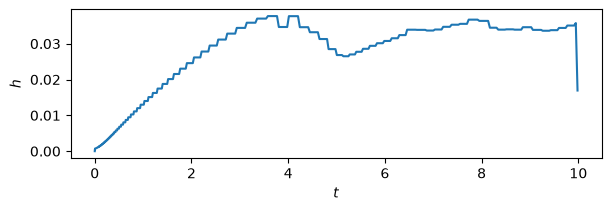

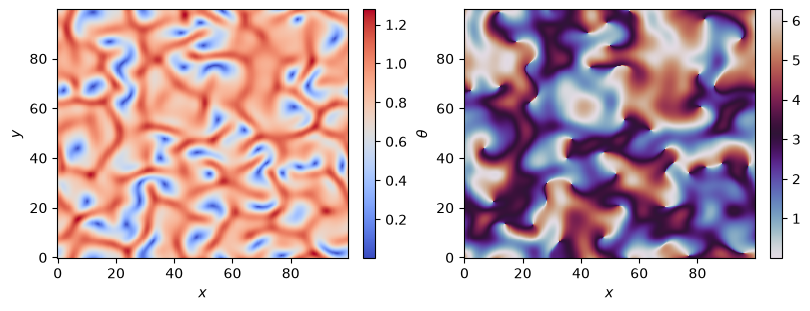

In [11]:
ys=sol2.y.reshape([2]+Ns+[-1]).transpose(3,0,1,2)
ts=sol2.t

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


Note that BDF takes larger steps that RK45. As the number of mesh points Ns increases, the system gets stiffer and RK45 takes increasingly smaller steps while BDF does not. The sparse LU scales well enough that BDF outperforms RK45 for large Ns.  Even though the pseudospectral discretization is generally superior to finite difference, BDF may be preferred for fine spatial resolution. Illustrate with a large system size.

In [17]:
Ns=[512,512]
Ls=[100.0,100.0]

cmd='%s ./rdcu -t %f -d %f -N %i,%i -L %f,%f -n 2 -v -D1 %s'%(loadstr,T,dt,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

 ./rdcu -t 10.000000 -d 0.100000 -N 512,512 -L 100.000000,100.000000 -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
1.000	3.848e+02	-7.110e-02	0.002944	3462	
runtime: 384.849331


0

runtime: 384.849331



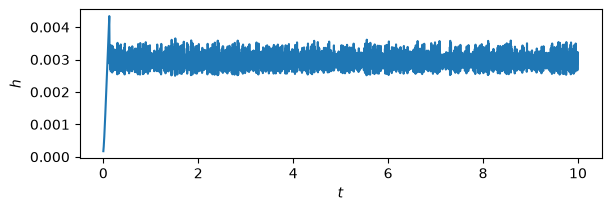

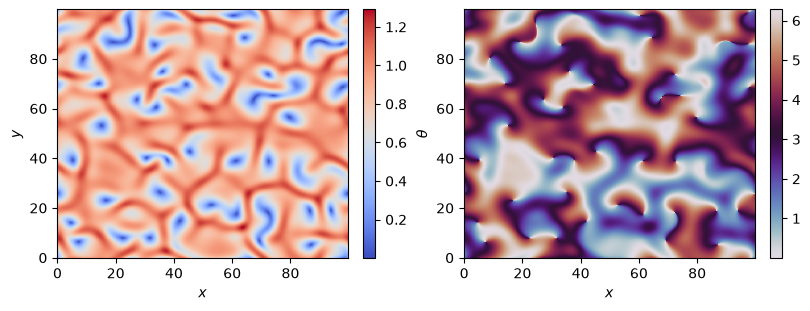

In [18]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


In [19]:
Ns=[512,512]
Ls=[100.0,100.0]

cmd='%s ./rdcu -t %f -d %f -N %i,%i -L %f,%f -S -n 2 -v -D1 %s'%(loadstr,T,dt,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

 ./rdcu -t 10.000000 -d 0.100000 -N 512,512 -L 100.000000,100.000000 -S -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Using random initial conditions
1.000	1.630e+02	-2.699e-02	0.038927	717	
runtime: 163.193884


0

runtime: 163.193884



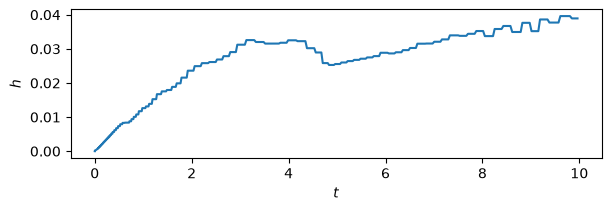

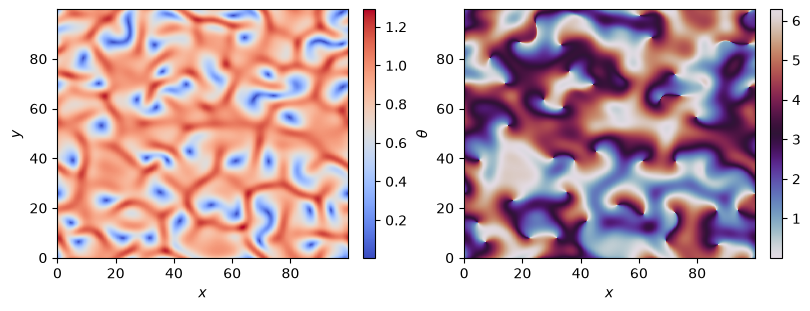

In [20]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()

For both integration methods, we can reload saved final states in FILEBASEfs.dat with the -R flag to continue

In [21]:
cmd='%s./rdcu -t %f -d %f -N %i,%i -L %f,%f -R -S -n 2 -v -D1 %s'%(loadstr,2*T,dt,Ns[0],Ns[1],Ls[0],Ls[1],filebase)
print(cmd)
os.system(cmd)

./rdcu -t 20.000000 -d 0.100000 -N 512,512 -L 100.000000,100.000000 -R -S -n 2 -v -D1 data/2dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + -2.000(u1_00)^1 + -2.000(u1_11)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -0.800(u0)^2(u1)^1 + -0.800(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 2.000(u0_00)^1 + 2.000(u0_11)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 0.800(u0)^3 + 0.800(u0)^1(u1)^2 + 0
Reloading final conditions from file
Restarting at t=10.001663 with h=0.038927
1.001	7.421e+01	-6.578e-02	0.032243	278	
runtime: 74.409080


0

runtime: 74.409080



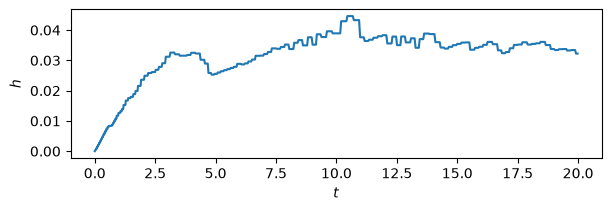

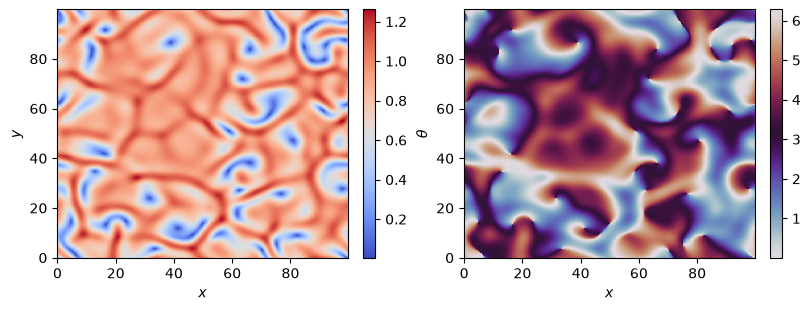

In [22]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='coolwarm')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
plt.colorbar()

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(Ns[1])/Ns[1]*Ls[1], R, cmap='twilight')
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')
plt.colorbar()

plt.show()


1D CGLE. Change parameters for an intermittency example.

In [23]:
Ns=[8192]
N=Ns[0]
Ls=[200.0] 
T=100

filebase='data/1dcgle'

b=0.1
c=2.0
couplings=['1.0,0,0,1', '1.0,0,4,1', '-%f,0,5,1'%(b),  \
           '-1.0,0,0,3', '-1.0,0,0,1,1,2', '1.0,1,1,1', \
           '1.0,1,5,1', '%f,1,4,1'%(b), \
           '-1.0,1,0,2,1,1', '-1.0,1,1,3', '%f,1,0,3'%(c), '%f,1,0,1,1,2'%(c), \
           '-%f,0,0,2,1,1'%(c),'-%f,0,1,3'%(c)]

file=open('%scoupling.dat'%(filebase),'w')
for line in couplings:
    print(line,file=file)
file.close()

cmd='%s ./rdcu -t %f -d %f -N %i -L %f -n 2 -v -D1 -S %s'%(loadstr,T,dt,Ns[0],Ls[0],filebase)
print(cmd)
os.system(cmd)

 ./rdcu -t 100.000000 -d 0.100000 -N 8192 -L 200.000000 -n 2 -v -D1 -S data/1dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + -0.100(u1_00)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -2.000(u0)^2(u1)^1 + -2.000(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 0.100(u0_00)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 2.000(u0)^3 + 2.000(u0)^1(u1)^2 + 0
Using random initial conditions
1.000	4.543e+01	-5.544e-03	0.028828	3737	
runtime: 45.437814


0

runtime: 45.437814



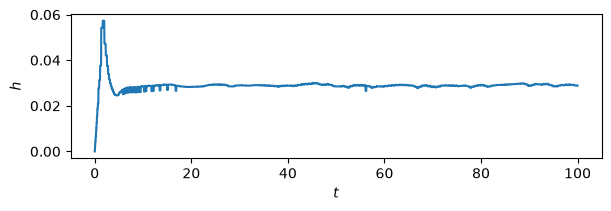

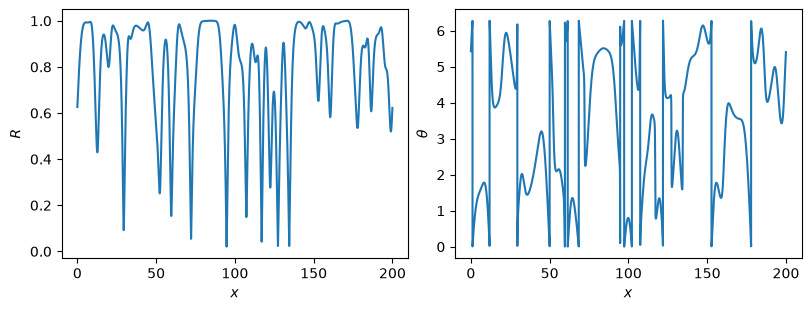

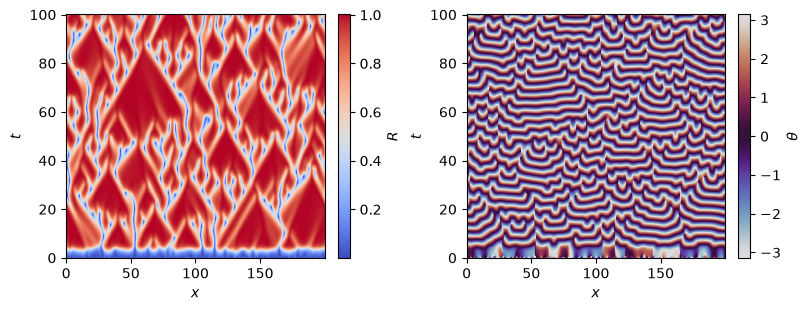

In [24]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

ys=np.fromfile(filebase+'states.dat').reshape([-1]+[2]+Ns)
ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5

plt.plot(np.arange(Ns[0])/Ns[0]*Ls[0], R)
ax.set_xlabel('$x$')
ax.set_ylabel('$R$')

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi

plt.plot(np.arange(Ns[0])/Ns[0]*Ls[0], R)
ax.set_xlabel('$x$')
ax.set_ylabel(r'$\theta$')

plt.show()

fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1)

R=(ys[:,0]**2+ys[:,1]**2)**0.5

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(ys.shape[0])*0.1, R,cmap='coolwarm')
plt.xlabel(r'$x$')
plt.ylabel(r'$t$')
plt.colorbar(label=r'$R$')

ax = fig.add_subplot(1,2,2)

R=np.atan2(ys[:,1],ys[:,0])

plt.pcolormesh(np.arange(Ns[0])/Ns[0]*Ls[0], np.arange(ys.shape[0])*0.1, R,cmap='twilight')
plt.xlabel(r'$x$')
plt.ylabel(r'$t$')
plt.colorbar(label=r'$\theta$')

plt.show()

3d CGLE. Change parameters for frozen vortices, and make a fancy animation.

In [5]:
Ns=[256,256,256]
Ls=[200.0,200.0,200.0]

Ns=[64,64,64]
Ls=[100.0,100.0,100.0]

N=Ns[0]

filebase='data/3dcgle'

b=0.0
c=1.5

couplings=['1.0,0,0,1', '1.0,0,8,1', '1.0,0,16,1', '1.0,0,24,1', '-%f,0,9,1'%(b), \
           '-%f,0,17,1'%(b), '-%f,0,25,1'%(b), '-1.0,0,0,3', '-1.0,0,0,1,1,2', '1.0,1,1,1', \
           '1.0,1,9,1', '1.0,1,17,1', '1.0,1,25,1', '%f,1,8,1'%(b),'%f,1,16,1'%(b), '%f,1,24,1'%(b), \
           '-1.0,1,0,2,1,1', '-1.0,1,1,3', '%f,1,0,3'%(c), '%f,1,0,1,1,2'%(c), \
           '-%f,0,0,2,1,1'%(c),'-%f,0,1,3'%(c)]

file=open('%scoupling.dat'%(filebase),'w')
for line in couplings:
    print(line,file=file)
file.close()

run for 500 time steps before saving dense output

In [20]:
T0=500
dt0=10
cmd='%s ./rdcu -s 2 -t %f -d %f -N %i,%i,%i -L %f,%f,%f -n 2 -v -D1 %s'%(loadstr,T0,dt0,Ns[0],Ns[1],Ns[2],Ls[0],Ls[1],Ls[2],filebase)
print(cmd)
os.system(cmd)

T=1000
dt=0.5
cmd='%s ./rdcu -t %f -d %f -N %i,%i,%i -L %f,%f,%f -n 2 -R -v -D1 %s'%(loadstr,T,dt,Ns[0],Ns[1],Ns[2],Ls[0],Ls[1],Ls[2],filebase)
print(cmd)
os.system(cmd)

 ./rdcu -s 2 -t 500.000000 -d 10.000000 -N 64,64,64 -L 100.000000,100.000000,100.000000 -n 2 -v -D1 data/3dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + 1.000(u0_22)^1 + -0.000(u1_00)^1 + -0.000(u1_11)^1 + -0.000(u1_22)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -1.500(u0)^2(u1)^1 + -1.500(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 1.000(u1_11)^1 + 1.000(u1_22)^1 + 0.000(u0_00)^1 + 0.000(u0_11)^1 + 0.000(u0_22)^1 + -1.000(u0)^2(u1)^1 + -1.000(u1)^3 + 1.500(u0)^3 + 1.500(u0)^1(u1)^2 + 0
Using random initial conditions
1.000	1.090e+03	-1.647e-03	0.054369	9225	
runtime: 1090.314381
 ./rdcu -t 1000.000000 -d 0.500000 -N 64,64,64 -L 100.000000,100.000000,100.000000 -n 2 -R -v -D1 data/3dcgle
Using coupling terms from file
u0'=1.000(u0)^1 + 1.000(u0_00)^1 + 1.000(u0_11)^1 + 1.000(u0_22)^1 + -0.000(u1_00)^1 + -0.000(u1_11)^1 + -0.000(u1_22)^1 + -1.000(u0)^3 + -1.000(u0)^1(u1)^2 + -1.500(u0)^2(u1)^1 + -1.500(u1)^3 + 0
u1'=1.000(u1)^1 + 1.000(u1_00)^1 + 

0

runtime: 671.407646



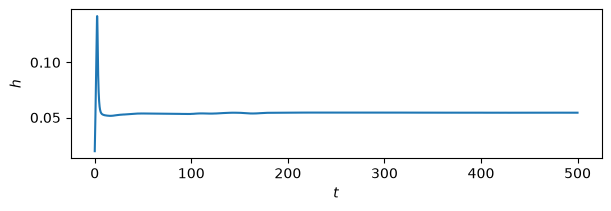

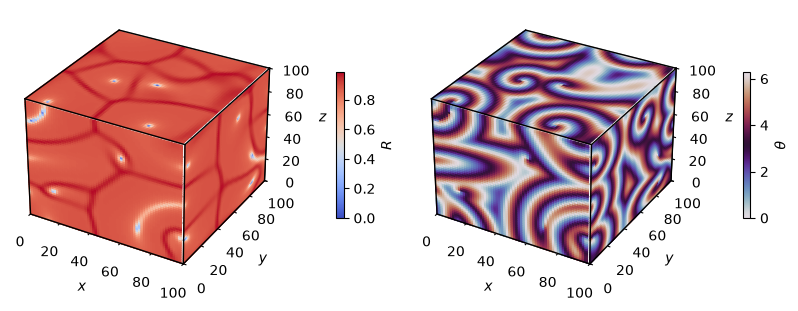

In [7]:
file=open(filebase+'.out')
print(file.readlines()[-1])
file.close()

file=open(filebase+'fs.dat','rb')
dat=file.read(8*2*Ns[0]*Ns[1]*Ns[2])
ys=np.array(struct.unpack('%id'%(2*Ns[0]*Ns[1]*Ns[2]),dat)).reshape([1,2]+Ns)

ts=np.fromfile(filebase+'times.dat')

fig = plt.figure(figsize=(6,2),layout='constrained')
plt.plot(ts[:-1],np.diff(ts))
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.show()


fig = plt.figure(figsize=(8,3), layout='constrained')
ax = fig.add_subplot(1,2,1, projection='3d')

R=(ys[-1][0]**2+ys[-1][1]**2)**0.5
Rmax=np.max(R)

Y,X=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[1])/Ns[1]*Ls[1])
Z=Ls[2]*np.ones(X.shape)
C=plt.get_cmap('coolwarm')(R[:,:,-1]/Rmax)
ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)

X,Z=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[2])/Ns[2]*Ls[2])
Y=0*np.ones(X.shape)
C=plt.get_cmap('coolwarm')(R[:,0,:].T/Rmax)
ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)

Z,Y=np.meshgrid(np.arange(Ns[1])/Ns[1]*Ls[1],np.arange(Ns[2])/Ns[2]*Ls[2])
X=Ls[0]*np.ones(X.shape)
C=plt.get_cmap('coolwarm')(R[-1,:,:]/Rmax)
ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
ax.plot([Ls[0],Ls[0]],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([0,Ls[0]],[0,0],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([0,Ls[0]],[0,0],[0,0], lw=1, c='black', alpha=1, zorder=10)
ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[0,0], lw=1, c='black', alpha=1, zorder=10)
ax.plot([0,0],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([Ls[0],Ls[0]],[Ls[1],Ls[1]],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([0,Ls[0]],[Ls[1],Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([0,0],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)

ax.set_xlim(0,Ls[0])
ax.set_ylim(0,Ls[1])
ax.set_zlim(0,Ls[2])

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')

cmap = plt.get_cmap('coolwarm')
norm = Normalize(vmin=0, vmax=Rmax)
fig.colorbar(ScalarMappable(norm=norm, cmap=cmap),ax=ax,location='right', label=r'$R$', shrink=0.5, pad=0.2)

ax = fig.add_subplot(1,2,2, projection='3d')

R=np.atan2(ys[-1][1],ys[-1][0])+np.pi
Rmax=2*np.pi

Y,X=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[1])/Ns[1]*Ls[1])
Z=Ls[2]*np.ones(X.shape)
C=plt.get_cmap('twilight')(R[:,:,-1]/Rmax)
ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)

X,Z=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[2])/Ns[2]*Ls[2])
Y=0*np.ones(X.shape)
C=plt.get_cmap('twilight')(R[:,0,:].T/Rmax)
ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)

Z,Y=np.meshgrid(np.arange(Ns[1])/Ns[1]*Ls[1],np.arange(Ns[2])/Ns[2]*Ls[2])
X=Ls[0]*np.ones(X.shape)
C=plt.get_cmap('twilight')(R[-1,:,:]/Rmax)
ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
ax.plot([Ls[0],Ls[0]],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([0,Ls[0]],[0,0],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([0,Ls[0]],[0,0],[0,0], lw=1, c='black', alpha=1, zorder=10)
ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[0,0], lw=1, c='black', alpha=1, zorder=10)
ax.plot([0,0],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([Ls[0],Ls[0]],[Ls[1],Ls[1]],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([0,Ls[0]],[Ls[1],Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
ax.plot([0,0],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)

ax.set_xlim(0,Ls[0])
ax.set_ylim(0,Ls[1])
ax.set_zlim(0,Ls[2])

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')

cmap = plt.get_cmap('twilight')
norm = Normalize(vmin=0, vmax=Rmax)
fig.colorbar(ScalarMappable(norm=norm, cmap=cmap),ax=ax,location='right',label=r'$\theta$', shrink=0.5, pad=0.2)

plt.show()

Plot frames and combine into a video. Plotting takes longer than generating the data...

rm: cannot remove 'data/3dcgleanimation/*.png': No such file or directory


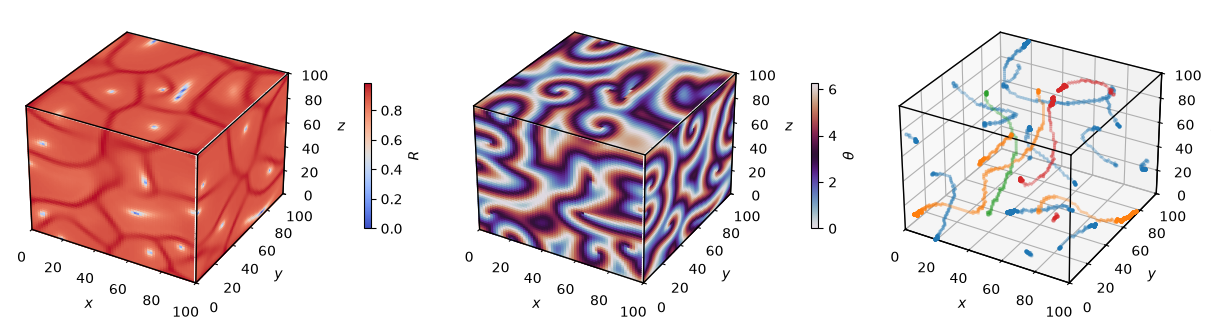

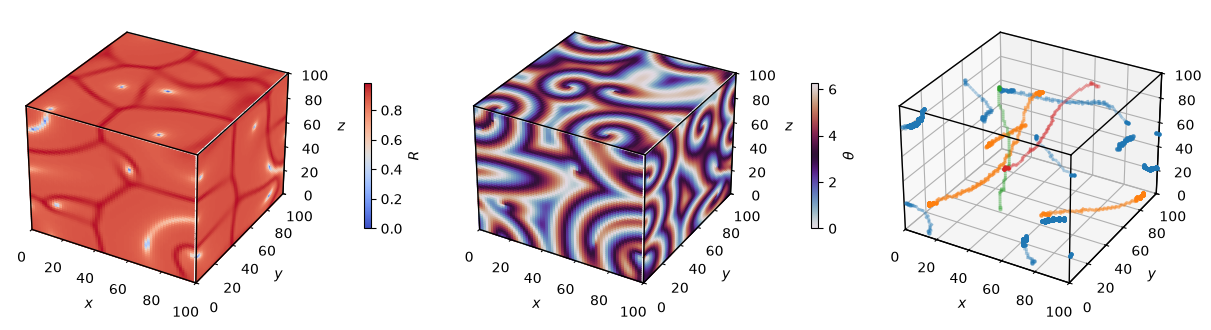

In [18]:
if not os.path.exists(filebase+'animation'):
    os.mkdir(filebase+'animation')
else:
    os.system('rm %sanimation/*.png'%(filebase))


Ns=np.array(Ns)
n0=int(T0/dt0)
nt=int((T-T0)/dt)


colors=plt.rcParams['axes.prop_cycle'].by_key()['color']

def wloop(th, axis1=0, axis2=1):
    dth1=np.mod(np.roll(th,1,axis=axis1)-th+np.pi,2*np.pi)-np.pi
    dth2=np.mod(np.roll(np.roll(th,1,axis=axis1),1,axis=axis2)-np.roll(th,1,axis=axis1)+np.pi,2*np.pi)-np.pi
    dth3=np.mod(np.roll(th,1,axis=axis2)-np.roll(np.roll(th,1,axis=axis1),1,axis=axis2)+np.pi,2*np.pi)-np.pi
    dth4=np.mod(th-np.roll(th,1,axis=axis2)+np.pi,2*np.pi)-np.pi
    return np.round((dth1+dth2+dth3+dth4)/(2*np.pi))

    
def makeplot(n,show=False,save=True):
    file=open(filebase+'states.dat','rb')
    file.seek((n0+n)*8*2*Ns[0]*Ns[1]*Ns[2])
    dat=file.read(8*2*Ns[0]*Ns[1]*Ns[2])
    ys=np.array(struct.unpack('%id'%(2*Ns[0]*Ns[1]*Ns[2]),dat)).reshape([2]+Ns.tolist())
    file.close()

    fig = plt.figure(figsize=(12,3), layout='constrained')
    ax = fig.add_subplot(1,3,1, projection='3d')
    
    R=(ys[0]**2+ys[1]**2)**0.5
    Rmax=np.max(R)
    
    Y,X=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[1])/Ns[1]*Ls[1])
    Z=Ls[2]*np.ones(X.shape)
    C=plt.get_cmap('coolwarm')(R[:,:,-1]/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    
    X,Z=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[2])/Ns[2]*Ls[2])
    Y=0*np.ones(X.shape)
    C=plt.get_cmap('coolwarm')(R[:,0,:].T/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    
    Z,Y=np.meshgrid(np.arange(Ns[1])/Ns[1]*Ls[1],np.arange(Ns[2])/Ns[2]*Ls[2])
    X=Ls[0]*np.ones(X.shape)
    C=plt.get_cmap('coolwarm')(R[-1,:,:]/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    ax.plot([Ls[0],Ls[0]],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[Ls[1],Ls[1]],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[Ls[1],Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    
    ax.set_xlim(0,Ls[0])
    ax.set_ylim(0,Ls[1])
    ax.set_zlim(0,Ls[2])
    
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_zlabel('$z$')
    
    cmap = plt.get_cmap('coolwarm')
    norm = Normalize(vmin=0, vmax=Rmax)
    fig.colorbar(ScalarMappable(norm=norm, cmap=cmap),ax=ax,location='right', label=r'$R$', shrink=0.5, pad=0.2)
    
    ax = fig.add_subplot(1,3,2, projection='3d')
    
    R=np.atan2(ys[1],ys[0])+np.pi
    Rmax=2*np.pi
    
    Y,X=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[1])/Ns[1]*Ls[1])
    Z=Ls[2]*np.ones(X.shape)
    C=plt.get_cmap('twilight')(R[:,:,-1]/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    
    X,Z=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[2])/Ns[2]*Ls[2])
    Y=0*np.ones(X.shape)
    C=plt.get_cmap('twilight')(R[:,0,:].T/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    
    Z,Y=np.meshgrid(np.arange(Ns[1])/Ns[1]*Ls[1],np.arange(Ns[2])/Ns[2]*Ls[2])
    X=Ls[0]*np.ones(X.shape)
    C=plt.get_cmap('twilight')(R[-1,:,:]/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    ax.plot([Ls[0],Ls[0]],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[Ls[1],Ls[1]],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[Ls[1],Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    
    ax.set_xlim(0,Ls[0])
    ax.set_ylim(0,Ls[1])
    ax.set_zlim(0,Ls[2])
    
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_zlabel('$z$')
    
    cmap = plt.get_cmap('twilight')
    norm = Normalize(vmin=0, vmax=Rmax)
    fig.colorbar(ScalarMappable(norm=norm, cmap=cmap),ax=ax,location='right',label=r'$\theta$', shrink=0.5, pad=0.2)

    ax = fig.add_subplot(1,3,3, projection='3d')

    th=np.atan2(ys[1],ys[0])+np.pi
    lines01=np.array(coo_array(wloop(th, axis1=0, axis2=1)).coords)
    lines12=np.array(coo_array(wloop(th, axis1=1, axis2=2)).coords)
    lines20=np.array(coo_array(wloop(th, axis1=2, axis2=0)).coords)
    
    lines=np.concatenate([lines01,lines12,lines20],axis=1)
    raveled=np.apply_along_axis(lambda row: np.ravel_multi_index(row,Ns), axis=0, arr=lines)
    arr=np.array(np.unravel_index(np.unique(raveled),shape=Ns))
    
    diffs=(arr[:,:,np.newaxis]-arr[:,np.newaxis,:])
    for axis in range(3):
        diffs[axis]=np.mod(diffs[axis]+Ns[axis]//2,Ns[axis])-Ns[axis]//2
    
    adj=np.linalg.norm(diffs,ord=np.inf,axis=0).astype(int)
    adj=np.where(adj<=1,adj,0)
    G=nx.from_numpy_array(adj)
    components=[component for component in nx.connected_components(G)]
        
    for i,component in enumerate(components):
        starts,ends=np.where(adj[list(component)]>0)
        starts=np.array(list(component))[starts]
        for j in range(len(starts)):
            l=np.linalg.norm(arr[:,starts[j]]-arr[:,ends[j]],ord=np.inf)
            if l<3:
                line=np.array([arr[:,starts[j]]*Ls/(Ns-1),arr[:,ends[j]]*Ls/(Ns-1)])
                plt.plot(*line.T,lw=2, alpha=0.1, marker=None,color=colors[i%len(colors)])
                if line[0][0]==0 or line[0][1]==Ls[1] or line[0][2]==0:
                    ax.scatter(*line[0],s=5,color=colors[i%len(colors)],alpha=0.5)
                if line[0][0]==Ls[0] or line[0][1]==0 or line[0][2]==Ls[2]:
                    ax.scatter(*line[0],s=5,color=colors[i%len(colors)],alpha=1.0)
                if line[1][0]==0 or line[1][1]==Ls[1] or line[1][2]==0:
                    ax.scatter(*line[0],s=5,color=colors[i%len(colors)],alpha=0.5)
                if line[1][0]==Ls[0] or line[1][1]==0 or line[1][2]==Ls[2]:
                    ax.scatter(*line[0],s=5,color=colors[i%len(colors)],alpha=1.0)

    ax.plot([Ls[0],Ls[0]],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[Ls[1],Ls[1]],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[Ls[1],Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    
    ax.set_xlim(0,Ls[0])
    ax.set_ylim(0,Ls[1])
    ax.set_zlim(0,Ls[1])

    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_zlabel('$z$')

    if save:
        plt.savefig(filebase+'animation/%04d.png'%(n))
    if show:
        plt.show()
    plt.close(fig)

makeplot(0,show=True,save=False)
makeplot(nt,show=True,save=False)

In [ ]:
start=timeit.default_timer()
pool=Pool(8,maxtasksperchild=1) 
pool.map(makeplot, range(nt))
pool.close()
stop=timeit.default_timer()
print("plot time: ", stop-start)

os.system('ffmpeg -y -r 30 -i %sanimation/'%(filebase)+'%04d.png'+ ' -c:v h264 -vf "pad=ceil(iw/2)*2:ceil(ih/2)*2,format=yuv420p" %sanimation.mp4'%(filebase))
display(Video('%sanimation.mp4'%(filebase)))
